In [1]:
import sys
sys.path.append("../")
import importlib
from functools import partial

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

import GNNInterpreter
from GNNInterpreter.gnninterpreter import *
importlib.reload(GNNInterpreter.gnninterpreter)

import gnn_xai_common
from gnn_xai_common import *
importlib.reload(gnn_xai_common.trainer)

<module 'gnn_xai_common.trainer' from '/repo/gnn-xai-common/gnn_xai_common/trainer.py'>

In [2]:
config = {
    "DATASET_NAME": "MUTAG", 
    "MAX_NODES": 20, 
    "device": "cuda"
}

# Data

In [3]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [4]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=10,
    batch_size=32,
    lr=1e-3,
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/10] train_loss=0.6423  val_acc=0.368
[002/10] train_loss=0.5529  val_acc=0.368
[003/10] train_loss=0.5628  val_acc=0.368
[004/10] train_loss=0.5482  val_acc=0.368
[005/10] train_loss=0.5460  val_acc=0.368
[006/10] train_loss=0.5524  val_acc=0.368
[007/10] train_loss=0.5378  val_acc=0.368
[008/10] train_loss=0.5342  val_acc=0.368
[009/10] train_loss=0.5259  val_acc=0.421
[010/10] train_loss=0.5149  val_acc=0.421
Test Accuracy: 0.789


# GED Approximator

Generating synthetic GED dataset with 4 perturbations per graph...
Created GED dataset with 752 pairs.


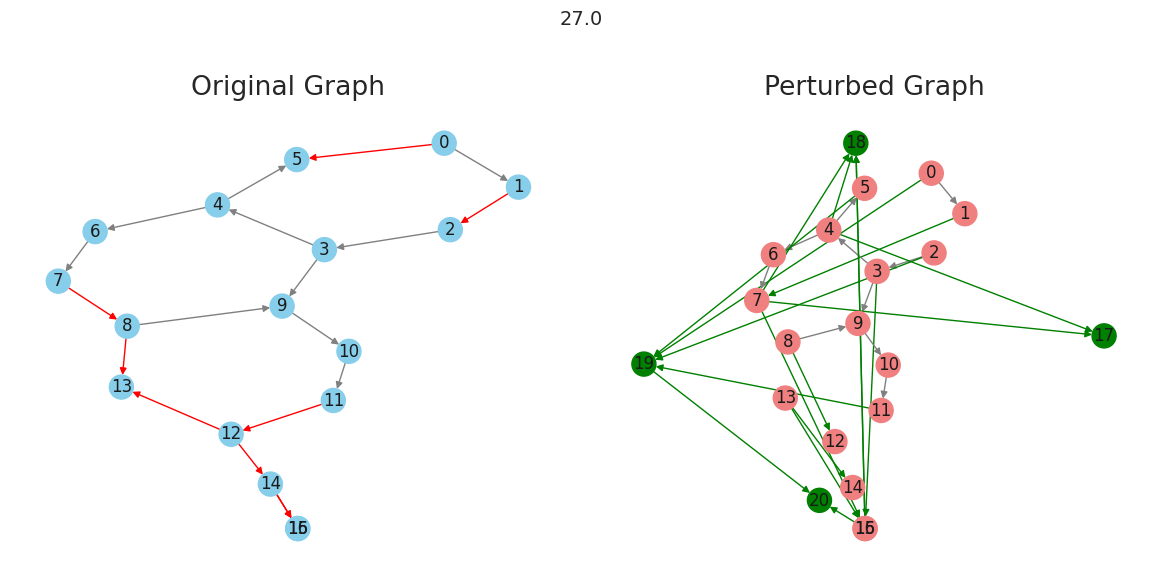

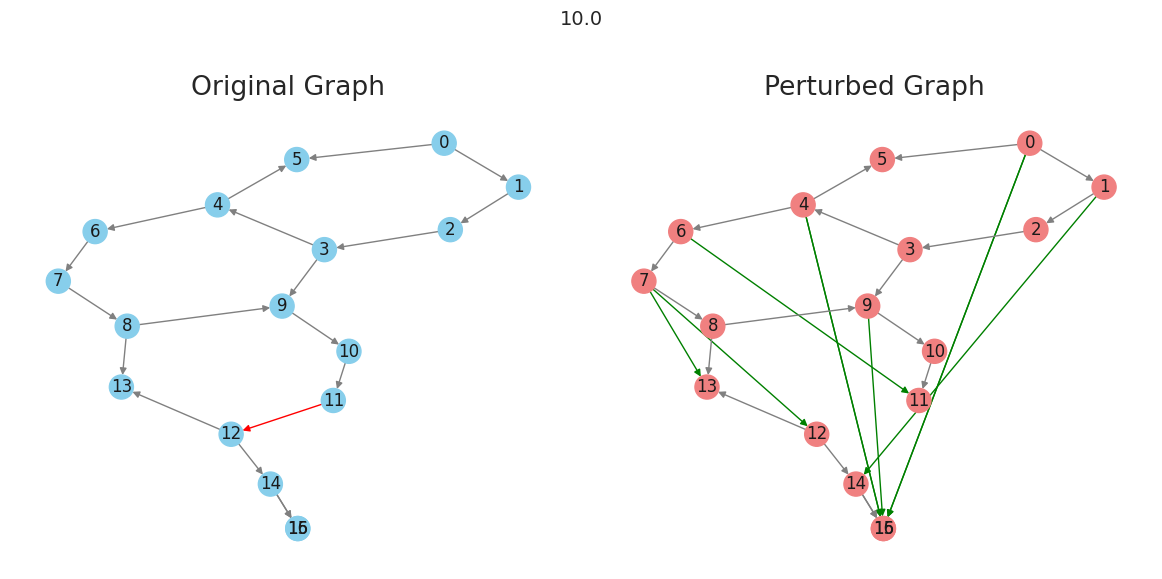

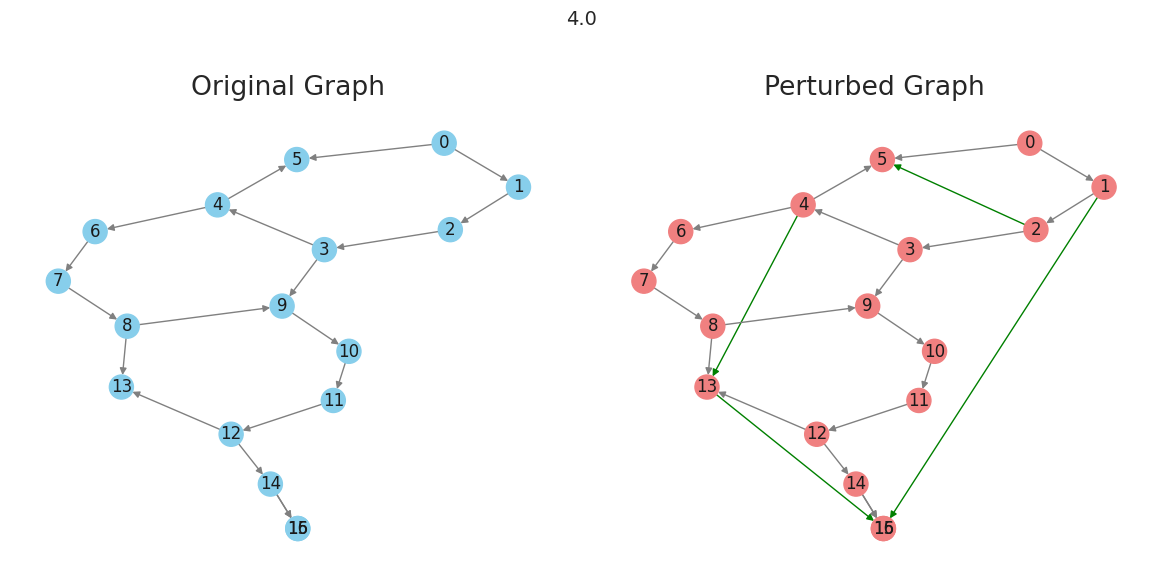

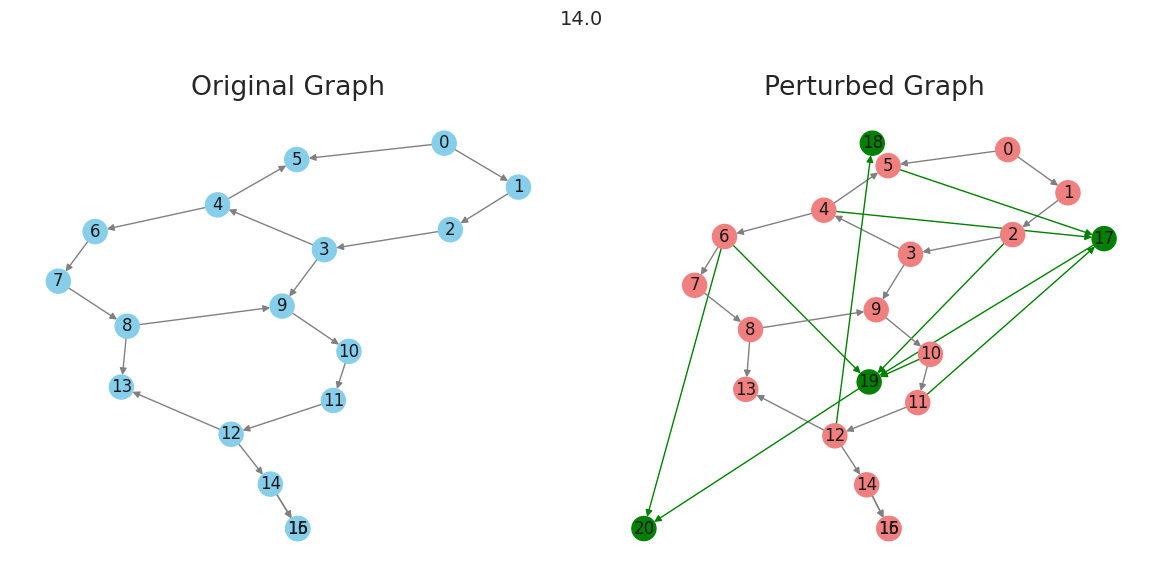

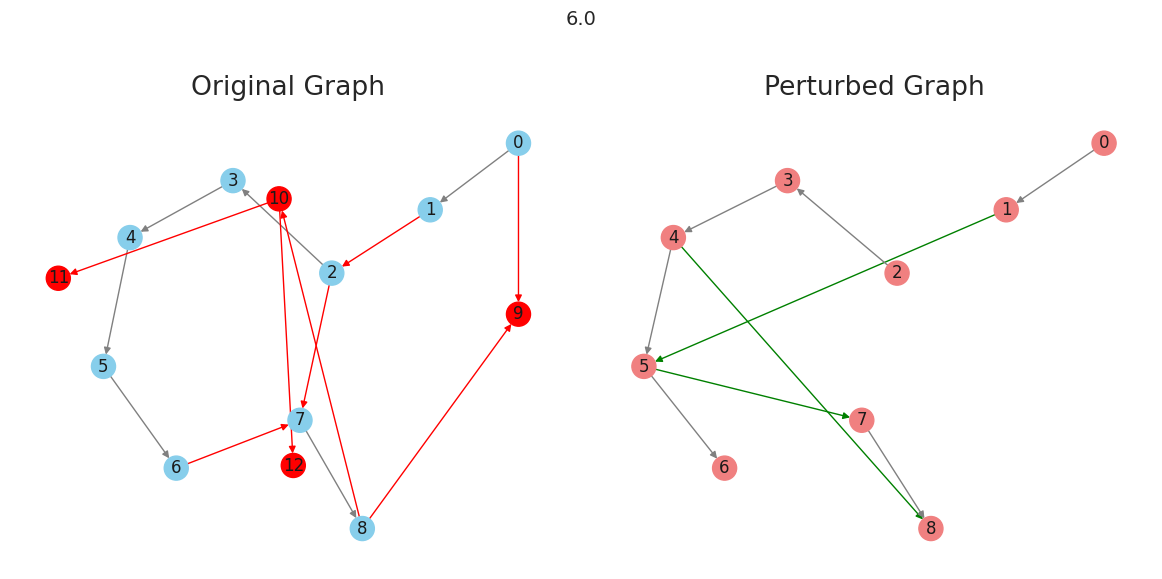

In [5]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=4,
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [6]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=64, 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=5, 
    device=config.get("device")
)

Training SimGNN:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 001 | Loss: 0.2097 | MSE(norm): 0.2097 | MSE(raw): 97.9775 | Corr(norm): 0.0361 | Corr(raw): 0.3712
Epoch 002 | Loss: 0.1641 | MSE(norm): 0.1641 | MSE(raw): 74.0217 | Corr(norm): 0.1042 | Corr(raw): 0.4860
Epoch 003 | Loss: 0.1483 | MSE(norm): 0.1483 | MSE(raw): 65.5403 | Corr(norm): 0.1170 | Corr(raw): 0.5228
Epoch 004 | Loss: 0.1502 | MSE(norm): 0.1502 | MSE(raw): 68.2681 | Corr(norm): 0.0377 | Corr(raw): 0.4445
Epoch 005 | Loss: 0.1417 | MSE(norm): 0.1417 | MSE(raw): 66.0249 | Corr(norm): 0.0929 | Corr(raw): 0.5011


# Distances

In [7]:
import new_src.graph_level_dist
importlib.reload(new_src.graph_level_dist)

from new_src.graph_level_dist import (
    neural_approx_ged_dist, 
    mcs_soft_graph_dist, 
    spectral_dist, 
    wl_graph_kernel_dist
)

nn_GED = neural_approx_ged_dist(
    data, model
)

max_common_sub = mcs_soft_graph_dist(
    data
)

spectral_dist = spectral_dist(
    data
) 

wl_graph_kernel_dist = wl_graph_kernel_dist(
    data
)

# Generator

In [8]:
def train_generator(cls_idx, data):
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=config.get("MAX_NODES"),
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", criterion=ClassScoreCriterion(class_idx=cls_idx, mode='maximize'), weight=50),
            dict(key="embeds", criterion=EmbeddingCriterion(target_embedding=mean_embeds[cls_idx]), weight=50),
            dict(key="cont_data", criterion=nn_GED, weight=1), 
            dict(key="cont_data", criterion=max_common_sub, weight=1), 
            dict(key="cont_data", criterion=spectral_dist, weight=1), 
            dict(key="cont_data", criterion=wl_graph_kernel_dist, weight=1), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
        device=config.get("device")
    )

    trainer.train(
        iterations=20,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

In [9]:
import new_src.utils
from new_src.utils import plot_graph
importlib.reload(new_src.utils)

gen_samples = 1

graphs_0 = []
graphs_1 = []
for i in range(gen_samples): 
    graphs_0.append(train_generator(0, data))
    graphs_1.append(train_generator(1, data))

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

# Evaluation

In [ ]:
import new_src.eval 
importlib.reload(new_src.eval)

from new_src.eval import eval_summary

dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
dist_to_1 = neural_approx_ged_dist(cls_split[1], model)

eval_summary(
    explainee, 
    graphs_0,
    graphs_1, 
    cls_split[0], 
    cls_split[1], 
    dist_to_0, 
    dist_to_1
)

RuntimeError: Expected all tensors to be on the same device, but got mat2 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_mm)

# GNNInterpreter